In [38]:
# XGBoost
# Gradient Boost

# Business Case :

### Based on given features we need to find whether an employee will leave the company or not.

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
# from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
from sklearn.pipeline import Pipeline
%matplotlib inline
warnings.filterwarnings('ignore')
#scikit learn 1.2.2 was used to write this notes

In [40]:
df=pd.read_csv("HR.csv")

# BASIC CHECKS

In [41]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


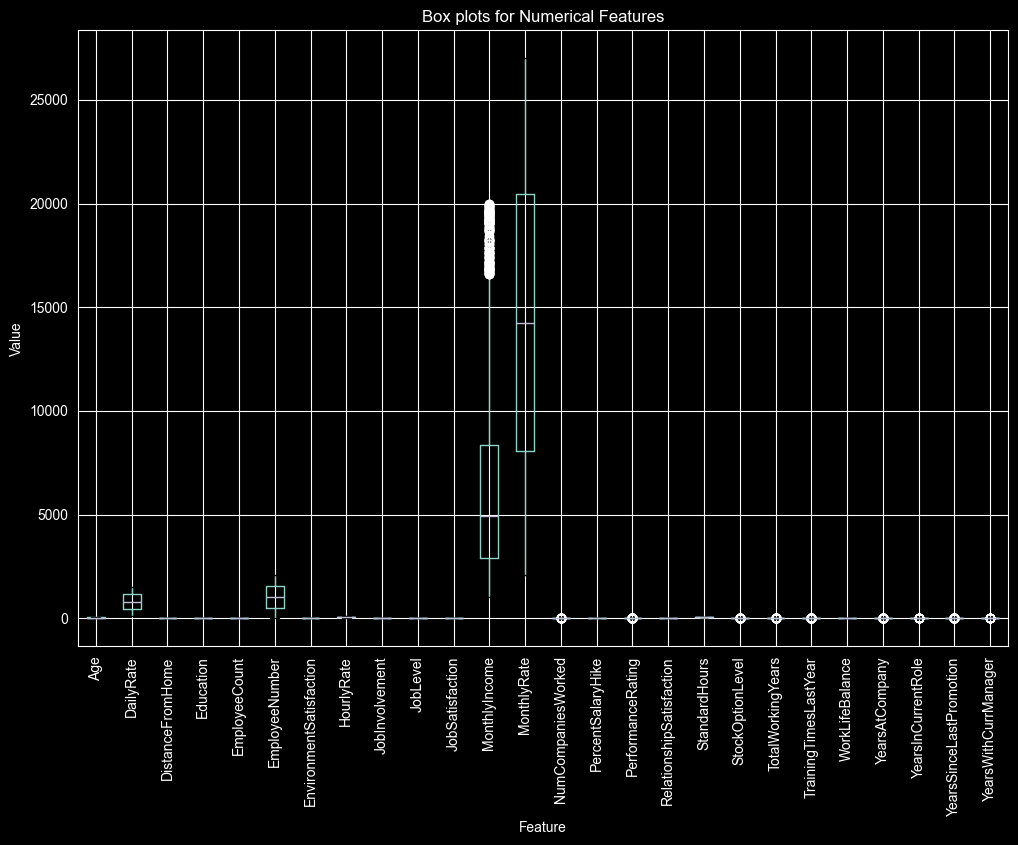

In [42]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int', 'float']).columns

# Create box plots for all numerical features
plt.figure(figsize=(12, 8))
df[numerical_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Box plots for Numerical Features')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.show()


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

- There are no null values in the dataset.
- Attrition is the target column

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [45]:
df.describe(include = "O")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


# EDA

# INSIGHTS FROM EDA

## Try writing your own insights

# Correlation

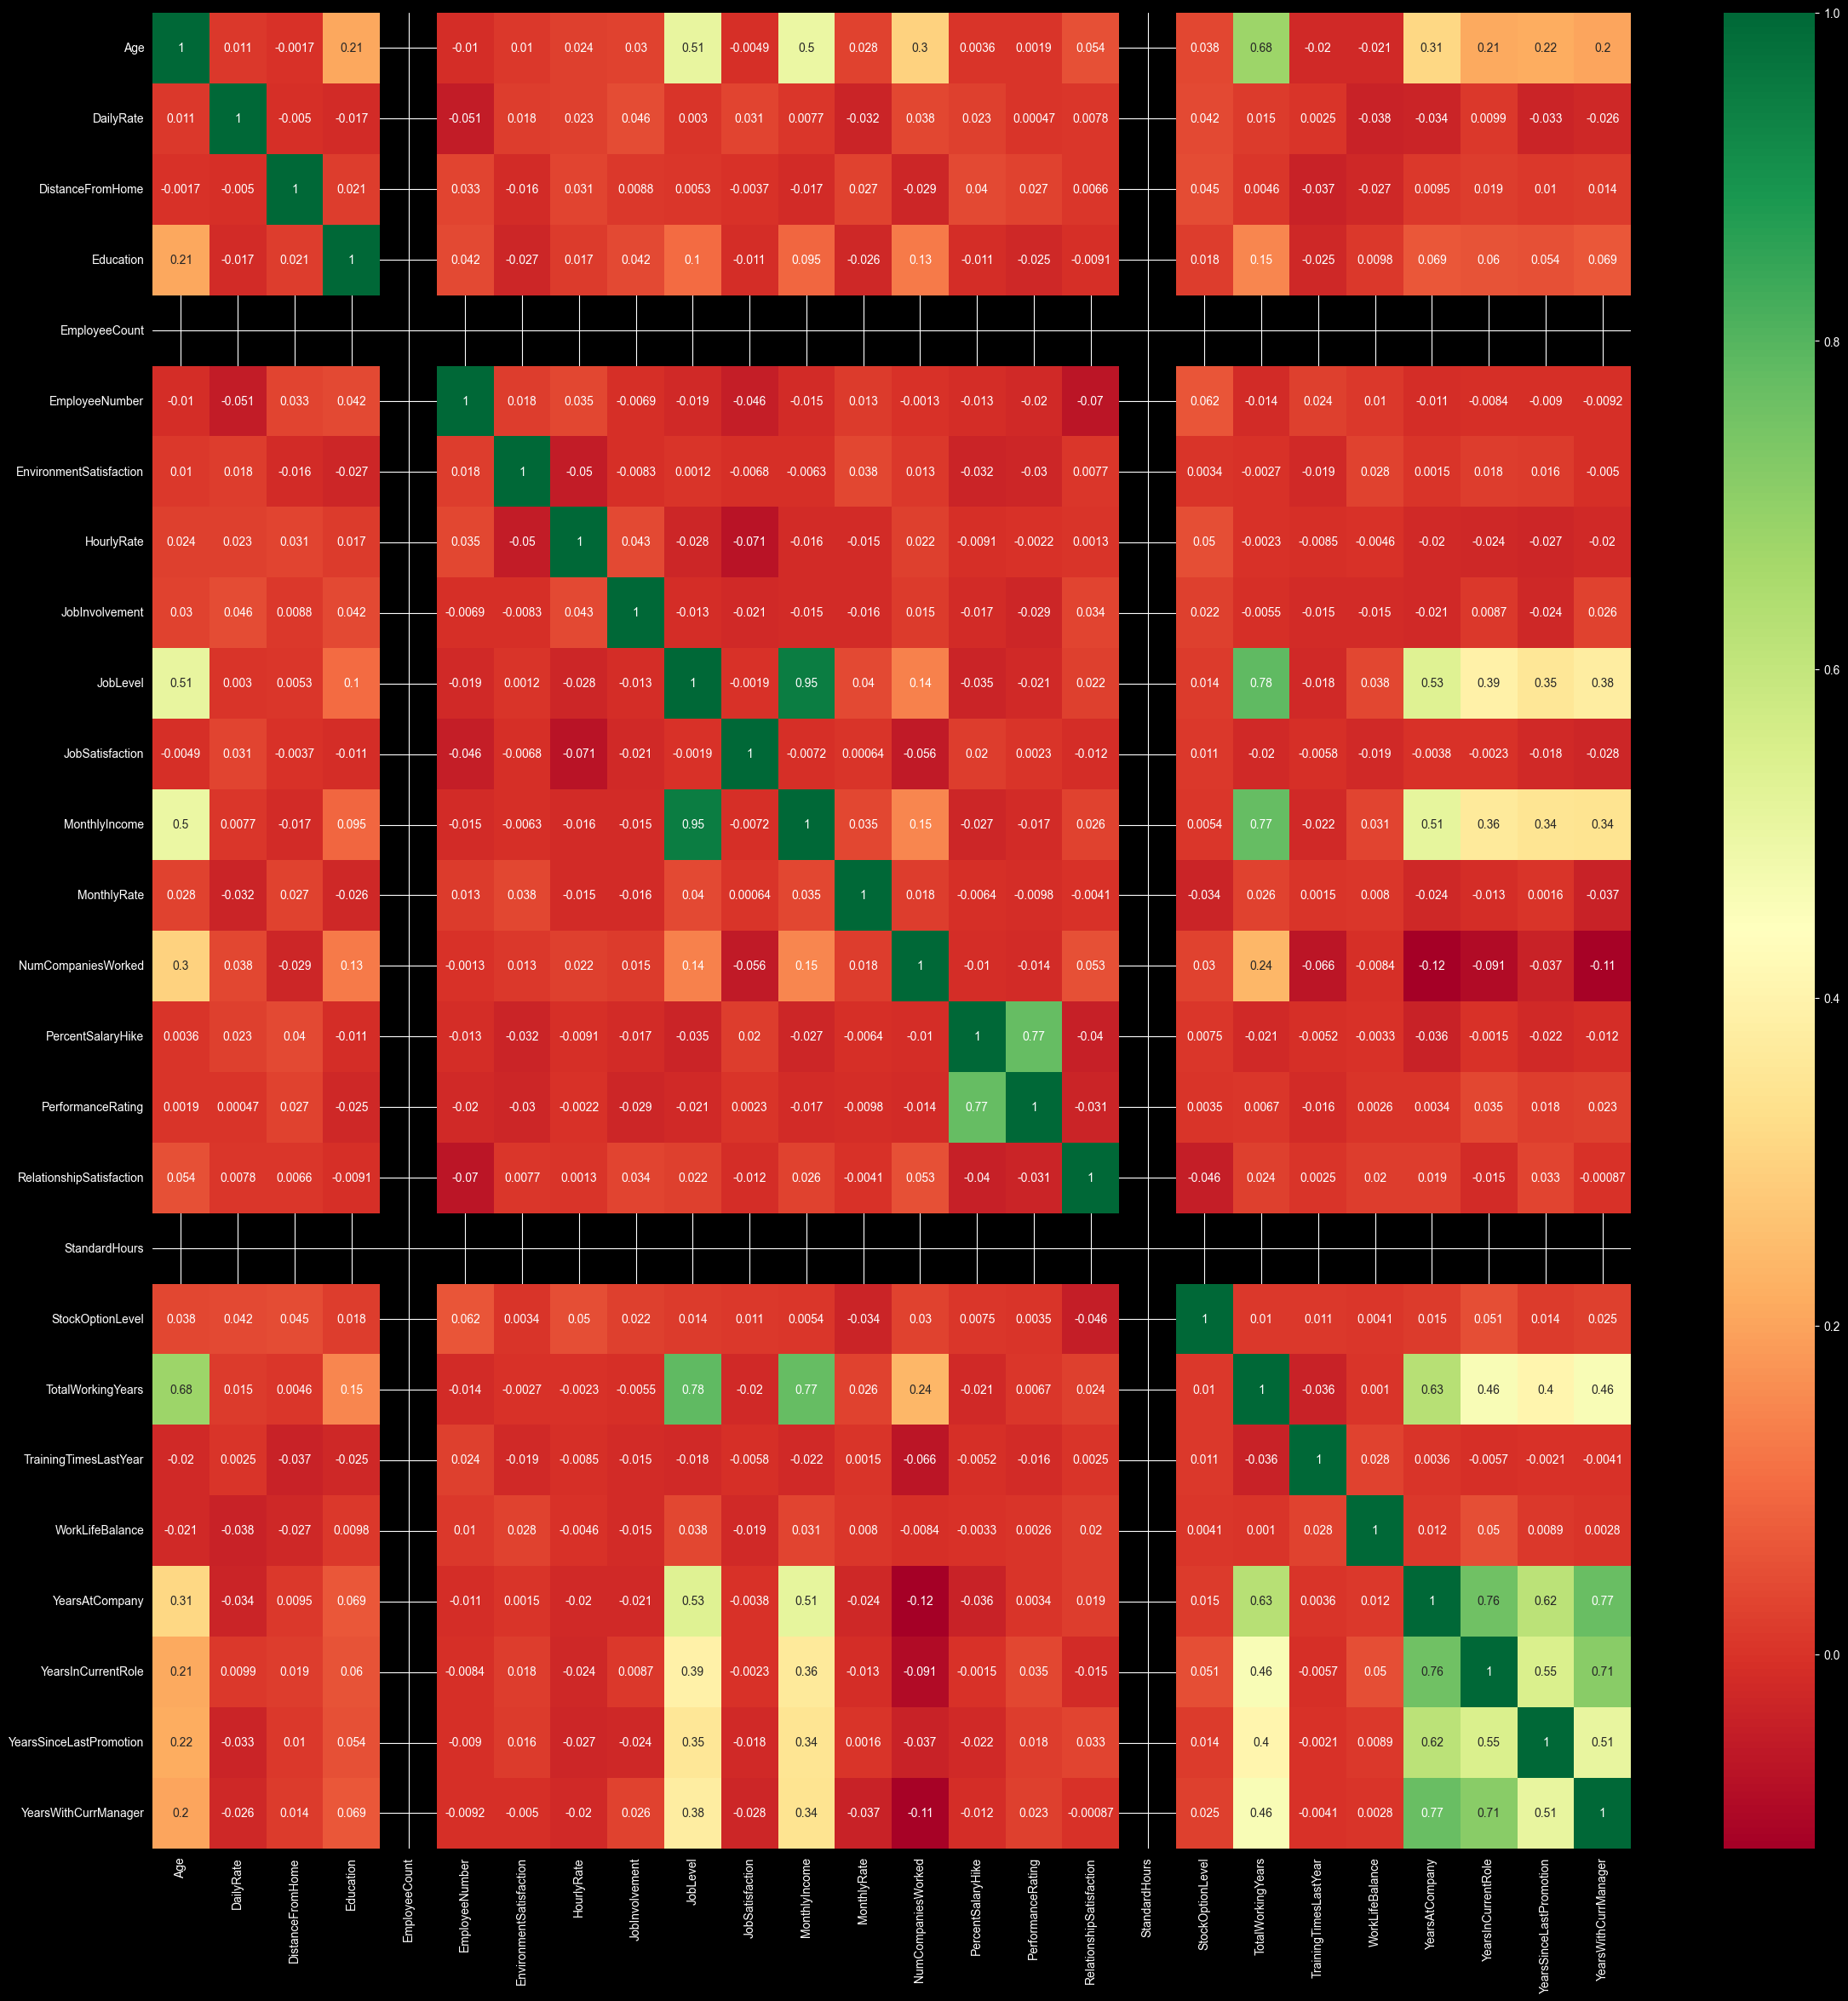

In [46]:
plt.figure(figsize=(28,28))#increase plot size
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(),cmap="RdYlGn",annot=True)
plt.show()

In [47]:
np.where(df.select_dtypes(include=['int', 'float']).corr()>0.9)

(array([ 0,  1,  2,  3,  5,  6,  7,  8,  9,  9, 10, 11, 11, 12, 13, 14, 15,
        16, 18, 19, 20, 21, 22, 23, 24, 25]),
 array([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 11, 10,  9, 11, 12, 13, 14, 15,
        16, 18, 19, 20, 21, 22, 23, 24, 25]))

- There is a high correlation between JobLevel and MonthlyIncome hence the MonthlyIncome column can be dropped.

# PRE-PROCESSING

In [48]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

**The below columns are numerical columns having continuous values and hence we will apply Standard Scaler for all these columns**
- Age
- DailyRate
- DistanceFromHome
- MonthlyRate
- HourlyRate
- NumCompaniesWorked
- TotalWorkingYears
- TrainingTimesLastYear
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager
- PercentSalaryHike

In [49]:
df[['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyRate', 'HourlyRate', 'NumCompaniesWorked', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager','PercentSalaryHike']]

,Age,DailyRate,DistanceFromHome,MonthlyRate,HourlyRate,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PercentSalaryHike
0,41,1102,1,19479,94,8,8,0,6,4,0,5,11
1,49,279,8,24907,61,1,10,3,10,7,1,7,23
2,37,1373,2,2396,92,6,7,3,0,0,0,0,15
3,33,1392,3,23159,56,1,8,3,8,7,3,0,11
4,27,591,2,16632,40,9,6,3,2,2,2,2,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,12290,41,4,17,3,5,2,0,3,17
1466,39,613,6,21457,42,4,9,5,7,7,1,7,15
1467,27,155,4,5174,87,1,6,0,6,2,0,3,20
1468,49,1023,2,13243,63,2,17,3,9,6,0,8,14


# BusinessTravel :

In [50]:
df.BusinessTravel.value_counts()

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

- We will use One Hot Encoder for this column.

# Department :

In [51]:
df.Department.value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

- We will use One hot encoder for this column.

# Education :

In [52]:
df.Education.value_counts()

Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64

- The values are already arranged ordinally so we don't need to do anything.

# EducationField :

In [53]:
df.EducationField.value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

- We will use One Hot Encoder.


# EnvironmentSatisfaction :

In [54]:
df.EnvironmentSatisfaction.value_counts()

EnvironmentSatisfaction
3    453
4    446
2    287
1    284
Name: count, dtype: int64

- The values were already arranged ordinally so we don't have to do anything.

# Gender :

In [55]:
df.Gender.value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

- We will apply One Hot Encoding to this column

# JobInvolvement :

In [56]:
df.JobInvolvement.value_counts()

JobInvolvement
3    868
2    375
4    144
1     83
Name: count, dtype: int64

- The values are already arranged in an orderly manner.

# JobLevel :

In [57]:
df.JobLevel.value_counts()

JobLevel
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64

- The values are already arranged in an ordinal manner.

# JobRole :

In [58]:
df.JobRole.value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

- We will use one hot encoding.

# JobSatisfaction :

In [59]:
df.JobSatisfaction.value_counts()

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

# MaritalStatus :

In [60]:
df.MaritalStatus.value_counts()

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

We will use One Hot Encoder for this column.

# OverTime :

In [61]:
df.OverTime.value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

- We will use Label encoder for this column.


# PerformanceRating :

In [62]:
df.PerformanceRating.value_counts()

PerformanceRating
3    1244
4     226
Name: count, dtype: int64

- There are no changes to be made in this column since it is already present in an orderly manner.

# RelationshipSatisfaction :

In [63]:
df.RelationshipSatisfaction.value_counts()

RelationshipSatisfaction
3    459
4    432
2    303
1    276
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

# StockOptionLevel :

In [64]:
df.StockOptionLevel.value_counts()

StockOptionLevel
0    631
1    596
2    158
3     85
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

# TrainingTimesLastYear :

In [65]:
df.TrainingTimesLastYear.value_counts()

TrainingTimesLastYear
2    547
3    491
4    123
5    119
1     71
6     65
0     54
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

# WorkLifeBalance :

In [66]:
df.WorkLifeBalance.value_counts()

WorkLifeBalance
3    893
2    344
4    153
1     80
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

**All the columns that have a prior hierarchical order will be left as it is and Ordinal encoder will not be applied to such columns.**

# Creating the preprocessing pipeline :

In [67]:
len(df.columns)

35

In [68]:
OHE_columns=['BusinessTravel','Department','MaritalStatus','EducationField','Gender','JobRole']
standard_scaler=['Age', 'DailyRate', 'DistanceFromHome','MonthlyRate', 'HourlyRate', 'NumCompaniesWorked', 'TotalWorkingYears',
                 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager','PercentSalaryHike']
label_encoder=['OverTime']
passthrough=['Education','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction','PercentSalaryHike','RelationshipSatisfaction',
             'StockOptionLevel','TrainingTimesLastYear','WorkLifeBalance','PerformanceRating']

# Steps of preprocesing for features:
- **LabelEncoder for**   :  'OverTime'
- **One hot encoder for**:  'BusinessTravel','Department','MaritalStatus','EducationField','Gender','JobRole'
- **Standard scaler for**:  'Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'MonthlyRate', 'HourlyRate', 'NumCompaniesWorked',
                            'TotalWorkingYears','TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                            'YearsWithCurrManager','PercentSalaryHike'
- **Pass through for**:     'Education','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction','PercentSalaryHike',
                            'RelationshipSatisfaction','StockOptionLevel','TrainingTimesLastYear','WorkLifeBalance','PerformanceRating'


In [69]:
class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)

In [70]:
def same(x):
    return x

In [71]:
no_trans=FunctionTransformer(same)

In [72]:
preprocessor = ColumnTransformer([
    ("OHE columns", OneHotEncoder(), OHE_columns),
    ("Label_encoder", ModifiedLabelEncoder(), label_encoder),
    ("Standard_scaler", StandardScaler(), standard_scaler),
    ('Pass_through',no_trans,passthrough)])

In [73]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OHE columns', ...), ('Label_encoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

In [74]:
with open("preprocessing.pkl","wb") as f:
    pickle.dump(preprocessor,f)